In [49]:
import importlib
from pathlib import Path
from IPython.display import display

try:
    import helpers.preprocess as prep
    import helpers.solver as solv
    import helpers.plotting_simple as ps

    importlib.reload(prep)
    importlib.reload(solv)
    importlib.reload(ps)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.plotting_simple import plot_structure_simple
except ImportError:
    import preprocess as prep
    import solver as solv
    import plotting_simple as ps

    importlib.reload(prep)
    importlib.reload(solv)
    importlib.reload(ps)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from plotting_simple import plot_structure_simple

# adjust this path if your JSON is elsewhere
model_path = "inputs/final_bridge/fort_griffin_main_span_revised_baseline.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

print("Model ran successfully")
print()
print("Model name")
print(clean_model["model_name"])
print()
print("Total DOF")
print(data["ndof"])
print()
print("Max absolute displacement")
print(abs(package["results"]["U"]).max())

Model ran successfully

Model name
fort_griffin_main_span_revised_baseline

Total DOF
234

Max absolute displacement
0.0005236346198902103


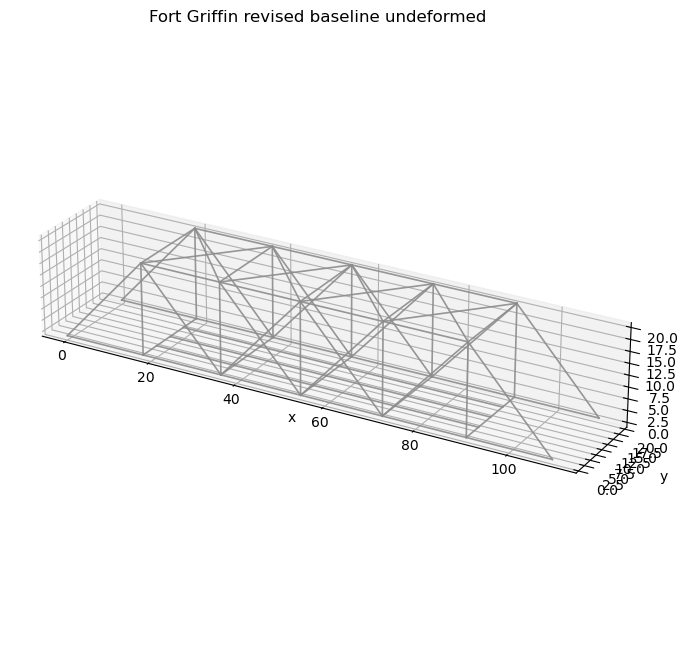

Saved outputs\final_bridge\simple_plots\fort_griffin_revised_baseline_undeformed.png


In [50]:
from pathlib import Path

plot_dir = Path("outputs/final_bridge/simple_plots")
plot_dir.mkdir(parents=True, exist_ok=True)

undeformed_path = plot_dir / "fort_griffin_revised_baseline_undeformed.png"
deformed_path = plot_dir / "fort_griffin_revised_baseline_undeformed_plus_deformed.png"

# Plot 1
# undeformed only
_ = plot_structure_simple(
    clean_model,
    data,
    U=None,
    scale=1.0,
    selector="all",
    show_undeformed=True,
    show_deformed=False,
    show_node_labels=False,
    show_element_labels=False,
    title="Fort Griffin revised baseline undeformed",
    save_path=str(undeformed_path),
)

print(f"Saved {undeformed_path}")

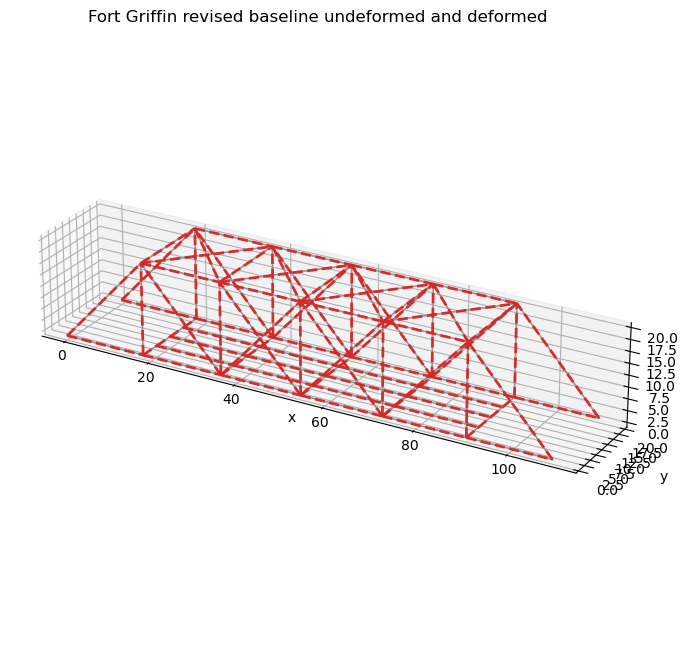

Saved outputs\final_bridge\simple_plots\fort_griffin_revised_baseline_undeformed_plus_deformed.png


In [51]:
# Plot 2
# undeformed plus deformed
# loads are off because no load display options are turned on
_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=80.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=False,
    show_element_labels=False,
    title="Fort Griffin revised baseline undeformed and deformed",
    save_path=str(deformed_path),
)

print(f"Saved {deformed_path}")

In [52]:
# optional quick display of key summaries
print("Support reactions at restrained DOFs")
print(package["results"]["reactions_at_restrained_dofs"][:20])

print()
print("First 20 displacement entries")
print(package["results"]["U"][:20])

Support reactions at restrained DOFs
[ 6.03961325e-14  0.00000000e+00  6.13894256e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -2.02009433e-02  4.40081341e+00
 -3.33214939e-01  2.68163366e+00  1.24118311e-02  1.24159268e+01
 -3.00154764e-01  1.89698863e+00  1.51534958e-02  1.26860683e+01
 -2.28948771e-01  3.80774939e-02  1.30424355e-02  1.25207776e+01]

First 20 displacement entries
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  2.42828531e-05  0.00000000e+00
 -2.22409586e-04  0.00000000e+00  0.00000000e+00  0.00000000e+00
  4.50665332e-05  0.00000000e+00 -3.79689696e-04  0.00000000e+00
  0.00000000e+00  0.00000000e+00  8.59552895e-05  0.00000000e+00]


In [53]:
import importlib
from IPython.display import display

try:
    import helpers.output_writer as ow
    importlib.reload(ow)
    from helpers.output_writer import write_run_outputs
except ImportError:
    import output_writer as ow
    importlib.reload(ow)
    from output_writer import write_run_outputs

output_dir, tables, global_summary, dof_summary = write_run_outputs(
    clean_model=clean_model,
    data=data,
    summary=summary,
    package=package,
    model_path=model_path,
    output_root="outputs/runs"
)

print(f"Outputs saved to {output_dir}")
print()
print(tables.keys())

Outputs saved to outputs\runs\fort_griffin_main_span_revised_baseline

dict_keys(['model_summary', 'nodal_loads', 'node_displacements', 'support_reactions', 'element_basic_data', 'element_local_displacements', 'element_local_end_forces', 'element_global_end_forces', 'element_derived_results'])


In [54]:
import importlib
from pathlib import Path

try:
    import helpers.plotting_simple as ps
    import helpers.plotting_plotly as pp3d

    importlib.reload(ps)
    importlib.reload(pp3d)

    from helpers.plotting_simple import plot_structure_simple
    from helpers.plotting_plotly import plot_structure_plotly
except ImportError:
    import plotting_simple as ps
    import plotting_plotly as pp3d

    importlib.reload(ps)
    importlib.reload(pp3d)

    from plotting_simple import plot_structure_simple
    from plotting_plotly import plot_structure_plotly

plot_dir_simple = Path("outputs/final_bridge/simple_plots")
plot_dir_plotly = Path("outputs/final_bridge/plotly_plots")
plot_dir_simple.mkdir(parents=True, exist_ok=True)
plot_dir_plotly.mkdir(parents=True, exist_ok=True)

simple_undeformed = plot_dir_simple / "fort_griffin_revised_baseline_undeformed.png"
simple_def_undef = plot_dir_simple / "fort_griffin_revised_baseline_undeformed_plus_deformed.png"

plotly_undef_html = plot_dir_plotly / "fort_griffin_revised_baseline_undeformed.html"
plotly_undef_png = plot_dir_plotly / "fort_griffin_revised_baseline_undeformed.png"

plotly_def_html = plot_dir_plotly / "fort_griffin_revised_baseline_undeformed_plus_deformed.html"
plotly_def_png = plot_dir_plotly / "fort_griffin_revised_baseline_undeformed_plus_deformed.png"

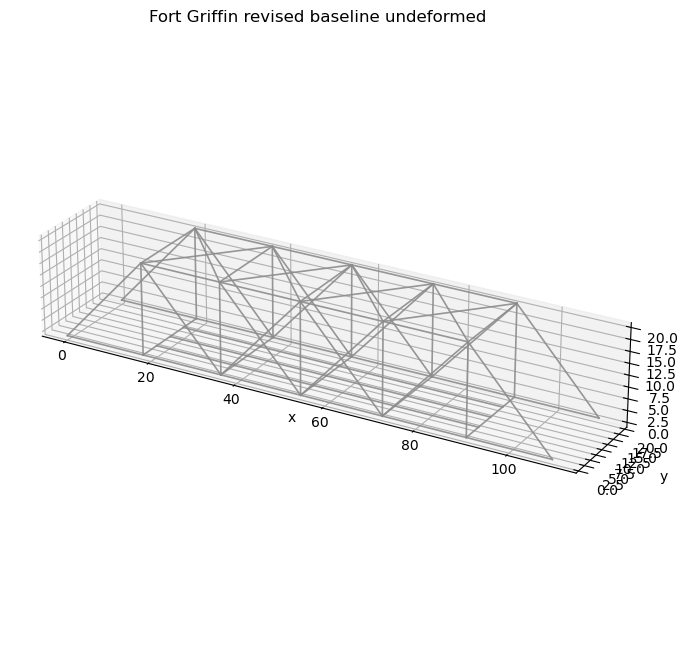

Saved outputs\final_bridge\simple_plots\fort_griffin_revised_baseline_undeformed.png


In [55]:
# Simple plot 1
_ = plot_structure_simple(
    clean_model,
    data,
    U=None,
    scale=1.0,
    selector="all",
    show_undeformed=True,
    show_deformed=False,
    show_node_labels=False,
    show_element_labels=False,
    title="Fort Griffin revised baseline undeformed",
    save_path=str(simple_undeformed),
)

print(f"Saved {simple_undeformed}")

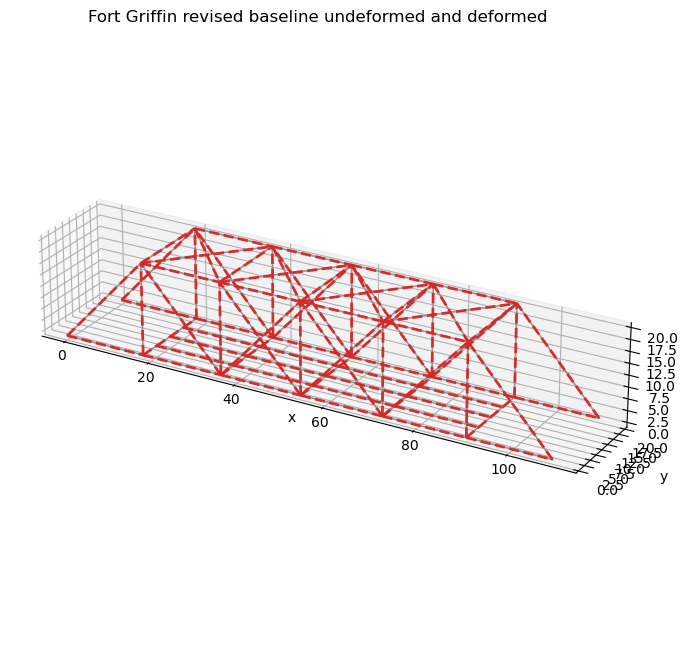

Saved outputs\final_bridge\simple_plots\fort_griffin_revised_baseline_undeformed_plus_deformed.png


In [56]:
# Simple plot 2
_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=80.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=False,
    show_element_labels=False,
    title="Fort Griffin revised baseline undeformed and deformed",
    save_path=str(simple_def_undef),
)

print(f"Saved {simple_def_undef}")

In [62]:
# Plotly plot 1
fig_undef = plot_structure_plotly(
    clean_model,
    data,
    U=None,
    scale=1.0,
    selector="all",
    show_undeformed=True,
    show_deformed=False,
    show_nodes=True,
    show_node_labels=False,
    show_element_hover=False,
    show_member_loads=False,
    title="Fort Griffin revised baseline undeformed",
    save_html=str(plotly_undef_html),
    save_png=str(plotly_undef_png),
)

fig_undef.show()
print(f"Saved {plotly_undef_html}")
print(f"Saved {plotly_undef_png}")

Saved outputs\final_bridge\plotly_plots\fort_griffin_revised_baseline_undeformed.html
Saved outputs\final_bridge\plotly_plots\fort_griffin_revised_baseline_undeformed.png


In [63]:
# Plotly plot 2
fig_def = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=80.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=False,
    show_member_loads=False,
    title="Fort Griffin revised baseline undeformed and deformed",
    save_html=str(plotly_def_html),
    save_png=str(plotly_def_png),
)

fig_def.show()
print(f"Saved {plotly_def_html}")
print(f"Saved {plotly_def_png}")

Saved outputs\final_bridge\plotly_plots\fort_griffin_revised_baseline_undeformed_plus_deformed.html
Saved outputs\final_bridge\plotly_plots\fort_griffin_revised_baseline_undeformed_plus_deformed.png


In [59]:
import pandas as pd

df_nodes = tables["node_displacements"].copy()

if "disp_mag" in df_nodes.columns:
    df_max_disp = df_nodes.sort_values("disp_mag", ascending=False)[
        ["node_id", "x", "y", "z", "ux", "uy", "uz", "disp_mag"]
    ].head(10)
else:
    df_nodes["disp_mag_calc"] = (df_nodes["ux"]**2 + df_nodes["uy"]**2 + df_nodes["uz"]**2) ** 0.5
    df_max_disp = df_nodes.sort_values("disp_mag_calc", ascending=False)[
        ["node_id", "x", "y", "z", "ux", "uy", "uz", "disp_mag_calc"]
    ].head(10)

display(df_max_disp)

,node_id,x,y,z,ux,uy,uz,disp_mag
31,32,54.528,10.0,0.0,0.000087,-7.063510e-23,-0.000524,0.000531
30,31,54.528,5.0,0.0,0.000087,-3.023926e-08,-0.000488,0.000495
32,33,54.528,15.0,0.0,0.000087,3.023926e-08,-0.000488,0.000495
34,35,72.704,10.0,0.0,0.000081,-9.180635e-23,-0.000475,0.000481
28,29,36.352,10.0,0.0,0.000093,-2.211273e-23,-0.000468,0.000477
33,34,72.704,5.0,0.0,0.000094,-2.602657e-08,-0.000439,0.000449
35,36,72.704,15.0,0.0,0.000094,2.602657e-08,-0.000439,0.000449
3,4,54.528,0.0,0.0,0.000086,0.000000e+00,-0.000433,0.000442
15,16,54.528,20.0,0.0,0.000086,0.000000e+00,-0.000433,0.000442
27,28,36.352,5.0,0.0,0.000079,-2.476818e-08,-0.000433,0.000440


In [60]:
df_react = tables["support_reactions"].copy()
display(df_react[["node_id", "x", "y", "z", "Rx", "Ry", "Rz", "Mx", "My", "Mz"]])

df_local = tables["element_local_end_forces"].copy()
df_derived = tables["element_derived_results"].copy()

# truss forces
if "axial_force" in df_derived.columns:
    df_truss = df_derived[df_derived["type"] == "3D_truss"].copy()
    df_truss["abs_axial"] = df_truss["axial_force"].abs()
    display(df_truss.sort_values("abs_axial", ascending=False).head(10))
else:
    print("No axial_force column found in element_derived_results")

    

,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz
0,1,0.000,0.0,0.0,6.039613e-14,0.000000,6.138943,0.000000,0.000000,0.000000
1,2,18.176,0.0,0.0,0.000000e+00,-0.020201,0.000000,4.400813,-0.333215,2.681634
2,3,36.352,0.0,0.0,0.000000e+00,0.012412,0.000000,12.415927,-0.300155,1.896989
3,4,54.528,0.0,0.0,0.000000e+00,0.015153,0.000000,12.686068,-0.228949,0.038077
4,5,72.704,0.0,0.0,0.000000e+00,0.013042,0.000000,12.520778,-0.172937,-1.847972
5,6,90.880,0.0,0.0,0.000000e+00,-0.020407,0.000000,8.414814,-0.127711,-2.772706
6,7,109.055,0.0,0.0,0.000000e+00,0.000000,6.838721,0.000000,0.000000,0.000000
7,8,18.176,0.0,20.0,0.000000e+00,2.600353,0.000000,0.000000,0.000000,0.000000
8,9,36.352,0.0,20.0,0.000000e+00,5.453821,0.000000,0.000000,0.000000,0.000000
9,10,54.528,0.0,20.0,0.000000e+00,5.755730,0.000000,0.000000,0.000000,0.000000


No axial_force column found in element_derived_results


In [61]:
# frame moments from local end force table
df_frame = df_local[df_local["type"] == "3D_frame"].copy()

for col in ["Mx_i_local", "My_i_local", "Mz_i_local", "Mx_j_local", "My_j_local", "Mz_j_local"]:
    if col not in df_frame.columns:
        print(f"Missing column: {col}")

df_frame["max_abs_end_moment"] = df_frame[
    ["Mx_i_local", "My_i_local", "Mz_i_local", "Mx_j_local", "My_j_local", "Mz_j_local"]
].abs().max(axis=1)

display(df_frame.sort_values("max_abs_end_moment", ascending=False).head(10))

,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local,max_abs_end_moment
54,309,3D_frame,4,31,0.015153,0.012410,3.264175,-0.228949,-12.686068,0.038077,-0.015153,-0.012410,-3.264175,0.228949,-3.634806,0.023972,12.686068
57,312,3D_frame,33,16,0.015153,-0.012410,-3.264175,0.228949,3.634806,-0.023972,-0.015153,0.012410,3.264175,-0.228949,12.686068,-0.038077,12.686068
61,316,3D_frame,36,17,0.013042,0.578700,-3.221384,0.172937,3.586142,1.045529,-0.013042,-0.578700,3.221384,-0.172937,12.520778,1.847972,12.520778
58,313,3D_frame,5,34,0.013042,-0.578700,3.221384,-0.172937,-12.520778,-1.847972,-0.013042,0.578700,-3.221384,0.172937,-3.586142,-1.045529,12.520778
53,308,3D_frame,30,15,0.012412,-0.594853,-3.195760,0.300155,3.562876,-1.077276,-0.012412,0.594853,3.195760,-0.300155,12.415927,-1.896989,12.415927
50,305,3D_frame,3,28,0.012412,0.594853,3.195760,-0.300155,-12.415927,1.896989,-0.012412,-0.594853,-3.195760,0.300155,-3.562876,1.077276,12.415927
65,320,3D_frame,39,18,-0.020407,0.832510,-2.166507,0.127711,2.417720,1.389844,0.020407,-0.832510,2.166507,-0.127711,8.414814,2.772706,8.414814
62,317,3D_frame,6,37,-0.020407,-0.832510,2.166507,-0.127711,-8.414814,-2.772706,0.020407,0.832510,-2.166507,0.127711,-2.417720,-1.389844,8.414814
55,310,3D_frame,31,32,-0.015153,-0.003432,0.356498,-0.097063,3.634387,-0.015633,0.015153,0.003432,-0.356498,0.097063,-5.416875,-0.001527,5.416875
56,311,3D_frame,32,33,-0.015153,0.003432,-0.356498,0.097063,5.416875,0.001527,0.015153,-0.003432,0.356498,-0.097063,-3.634387,0.015633,5.416875
